## SDM274 Assignment 04 - Logistic Regression

**Requirements**

Use the data set of previous homework assignment, namely wine.data.

Remove one class of wine samples from the dataset, retaining the other two classes to generate a new dataset. Consider the logistic regression model and cross-entropy loss function to address the binary classification problem of wine.

1. Write code to split the dataset into a training set and a test set in the ratio of (0.7, 0.3).

2. Write codes for Mini-batch update and Stochastic update to train the model.

3. Use the trained model to make predictions on the test set, and write code to evaluate the model's classification performance using accuracy, recall, precision, and F1 score.

4. Analyze and conclude the difference between perceptron and logistic regression model. 

Use the following packages mainly:
- Numpy for matrix operations and data manipulation.
- Pandas for data manipulation.
- Matplotlib for data visualization.

In [124]:
from enum import Enum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from matplotlib import cm

%matplotlib inline
# %matplotlib ipympl

Then implement the Perceptron algorithm in **LogisticRegression** class. Like the implementation in the previous assignment, we add SGD, BGD and MBGD methods to train the model; support min-max normalization and mean normalization:

In [125]:
class OptimizerType(Enum):
    SGD = 1
    BGD = 2
    MBGD = 3

class NormalizationType(Enum):
    NONE = 0
    MINMAX = 1
    MEAN = 2

class LogisticRegression:
    def __init__(self, dim = 1, learning_rate = 0.0001, max_iterations = 1000, tolerance = None, no_improve_threshold = 6, normalization_type = NormalizationType.NONE, optimizer_type = OptimizerType.SGD, batch_size = None):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.normalization_type = normalization_type
        self.tolerance = tolerance
        self.no_improve_threshold = no_improve_threshold

        self.optimizer_type = optimizer_type
        self.batch_size = batch_size
        if optimizer_type == OptimizerType.MBGD and batch_size is None:
            raise ValueError("batch_size should be specified for MBGD.")

        self.w = np.zeros(dim + 1)
        
        self.loss_history = None
        self.w_history = None
    
    @staticmethod
    def extend_X(X):
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def _min_max_normalize(self, X, record_params = False):
        if record_params:
            self.X_min, self.X_max = np.min(X, axis = 0), np.max(X, axis = 0)
        with np.errstate(divide = 'ignore', invalid = 'ignore'):
            X_normalized = (X - self.X_min) / (self.X_max - self.X_min)
        return np.where(np.isnan(X_normalized), X, X_normalized)

    def _mean_normalize(self, X, record_params = False): # TODO
        if record_params:
            self.X_mean, self.X_std = np.mean(X, axis = 0), np.std(X, axis = 0)
        with np.errstate(divide = 'ignore', invalid = 'ignore'):
            X_normalized = (X - self.X_mean) / self.X_std
        return np.where(np.isnan(X_normalized), X, X_normalized)
    
    def _normalize(self, X, record_params = False):
        if self.normalization_type == NormalizationType.MINMAX:
            return self._min_max_normalize(X, record_params)
        elif self.normalization_type == NormalizationType.MEAN:
            return self._mean_normalize(X, record_params)
        return X
    
    @staticmethod
    def _y(X, w, x_left_bound = -100, x_right_bound = 100):
        X_ext = LogisticRegression.extend_X(X)
        return 1 / (1 + np.exp(np.clip(-X_ext @ w, x_left_bound, x_right_bound)))
    
    def y(self, X, w = None, x_left_bound = -100, x_right_bound = 100):
        w = self.w if w is None else w
        X_norm = self._normalize(X)
        return LogisticRegression._y(X_norm, w, x_left_bound, x_right_bound)

    @staticmethod
    def _predict(X, w):
        return (LogisticRegression._y(X, w) >= 0.5).astype(int)
    
    def predict(self, X, w = None):
        w = self.w if w is None else w
        X_norm = self._normalize(X)
        return LogisticRegression._predict(X_norm, w)
    
    @staticmethod
    def _loss(X, t, w):
        y = LogisticRegression._y(X, w)
        return np.mean(-t * np.log(y + 1e-10) - (1 - t) * np.log(1 - y + 1e-10))
    
    def loss(self, X, t, w = None):
        w = self.w if w is None else w
        X_norm = self._normalize(X)
        return LogisticRegression._loss(X_norm, t, w)

    @staticmethod
    def _gradients(X, t, w):
        X_ext = LogisticRegression.extend_X(X)
        # print(-X_ext.T @ (t - LogisticRegression._y(X, w)))
        return -X_ext.T @ (t - LogisticRegression._y(X, w))
    
    def optimize(self, X, t):
        # Normalization for the first time
        X_norm = self._normalize(X, record_params = True)

        # Initialize history
        if self.tolerance is not None:
            last_loss = np.inf
        self.w_history = []
        self.loss_history = []

        # Optimization loop
        no_improve_count = 0
        for i in range(self.max_iterations):
            # Select samples
            _X, _t = X_norm, t
            if self.optimizer_type == OptimizerType.SGD:
                indices = np.random.randint(0, _X.shape[0])
                _X, _t = _X[indices:(indices + 1)], _t[indices:(indices + 1)]
            elif self.optimizer_type == OptimizerType.MBGD:
                indices = np.random.choice(_X.shape[0], self.batch_size, replace = False)
                _X, _t = _X[indices], _t[indices]

            # Calculate gradients on the selected samples
            grads = self._gradients(_X, _t, self.w)

            # Update weights
            self.w -= self.learning_rate * grads

            # Record history
            new_loss = self._loss(X_norm, t, self.w)
            self.w_history.append(self.w.copy())
            self.loss_history.append(new_loss)

            # Calculate overall loss and check convergence
            if self.tolerance is not None:
                if np.abs(new_loss - last_loss) < self.tolerance:
                    no_improve_count += 1
                    if no_improve_count >= self.no_improve_threshold:
                        print(f"Converged at iteration {i}.")
                        break
                else:
                    no_improve_count = 0
                last_loss = new_loss

Data splitting utility function **random_split** modified from HA-02.pdf:

In [126]:
def random_split(X, y, test_size = 0.2, seed = None):
    if seed is not None:
        np.random.seed(seed)

    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split_index = int(len(X) * (1 - test_size))
    train_indices, test_indices = indices[:split_index], indices[split_index:]

    X_train, y_train = X[train_indices], y[train_indices]
    X_test, y_test = X[test_indices], y[test_indices]

    return X_train, y_train, X_test, y_test

And finally a utility function **show_results** to print the optimized results and the evaluation metrics (accuracy, recall, precision, f1_score), as well as the loss curve (if the parameter show_plot is set to True):

In [127]:
def show_results(model, X_train, t_train, X_test, t_test, show_plot = False, fig_scale = 2):
    # Optimization results
    print('Optimized result:\t', model.w)
    print('Optimized loss:\t', model.loss(X_train, t_train))

    # Test results (TODO)
    t_pred_train = model.predict(X_train)
    t_pred_test = model.predict(X_test)
    accuracy_train = np.mean(t_pred_train == t_train)
    accuracy_test = np.mean(t_pred_test == t_test)
    print('Accuracy (Train):\t', accuracy_train)
    print('Accuracy (Test):\t', accuracy_test)
    recall_train = np.mean(t_pred_train[t_train == 1] == 1)
    recall_test = np.mean(t_pred_test[t_test == 1] == 1)
    print('Recall (Train):\t\t', recall_train)
    print('Recall (Test):\t\t', recall_test)
    precision_train = np.mean(t_train[t_pred_train == 1] == 1)
    precision_test = np.mean(t_test[t_pred_test == 1] == 1)
    print('Precision (Train):\t', precision_train)
    print('Precision (Test):\t', precision_test)
    f1_train = 2 * precision_train * recall_train / (precision_train + recall_train)
    f1_test = 2 * precision_test * recall_test / (precision_test + recall_test)
    print('F1 Score (Train):\t', f1_train)
    print('F1 Score (Test):\t', f1_test)

    if show_plot:
        # Plot
        fig = plt.figure(figsize = (16 * fig_scale, 4.5 * fig_scale))
        fig.suptitle(f'(learning_rate = {model.learning_rate}, max_iterations = {model.max_iterations}, tolerance = {model.tolerance}, normalization_type = {model.normalization_type}, optimizer_type = {model.optimizer_type}{", batch_size = " + str(model.batch_size) if model.optimizer_type == OptimizerType.MBGD else ""})', fontsize = 8 * fig_scale)

        # Loss curve
        ax = fig.add_subplot(111)
        ax.plot(model.loss_history)
        ax.tick_params(labelsize = 6 * fig_scale)
        ax.set_xlabel('Iteration', fontsize = 6 * fig_scale)
        ax.set_ylabel('Loss', fontsize = 6 * fig_scale)
        ax.set_title('Loss Curve', fontsize = 8 * fig_scale)

        # Show plot
        plt.show()

Load the dataset from `wine.data` and split it into training and testing sets with a ratio of 0.3 for test data. And then we drop one class of wine samples (class 3) to generate a binary classification problem. Let class 1 be the negative class and class 2 be the positive class:

In [128]:
# Load data
wine_csv = pd.read_csv('wine.data', header = None)
t_train = wine_csv[0].values
X_train = wine_csv.drop(0, axis = 1).values

# drop the data with label 3, change label 1 to Class 0 and label 2 to Class 1
drop_flag = t_train != 3
X_train, t_train = X_train[drop_flag], t_train[drop_flag]
t_train[t_train == 1] = 0
t_train[t_train == 2] = 1

# split the data
X_train, t_train, X_test, y_test = random_split(X_train, t_train, test_size = 0.3, seed = 42)
print(X_train.shape, t_train.shape, X_test.shape, y_test.shape)

(91, 13) (91,) (39, 13) (39,)


Use the `LogisticRegression` class to train the model. First we do not normalize the data, and use SGD, BGD and MBGD separately to train the model:

Optimized result:	 [ 9.83711481e-04  9.91968822e-03  8.96920465e-04  1.58554567e-03
  2.37858223e-02  6.54475270e-02  1.29772619e-03  7.03395337e-04
  4.20638397e-04  1.27893752e-03  5.05133140e-06  1.13386871e-03
  2.06868548e-03 -9.71249804e-03]
Optimized loss:	 0.24165351772092195
Accuracy (Train):	 0.8901098901098901
Accuracy (Test):	 0.8974358974358975
Recall (Train):		 0.8913043478260869
Recall (Test):		 0.88
Precision (Train):	 0.8913043478260869
Precision (Test):	 0.9565217391304348
F1 Score (Train):	 0.8913043478260869
F1 Score (Test):	 0.9166666666666666


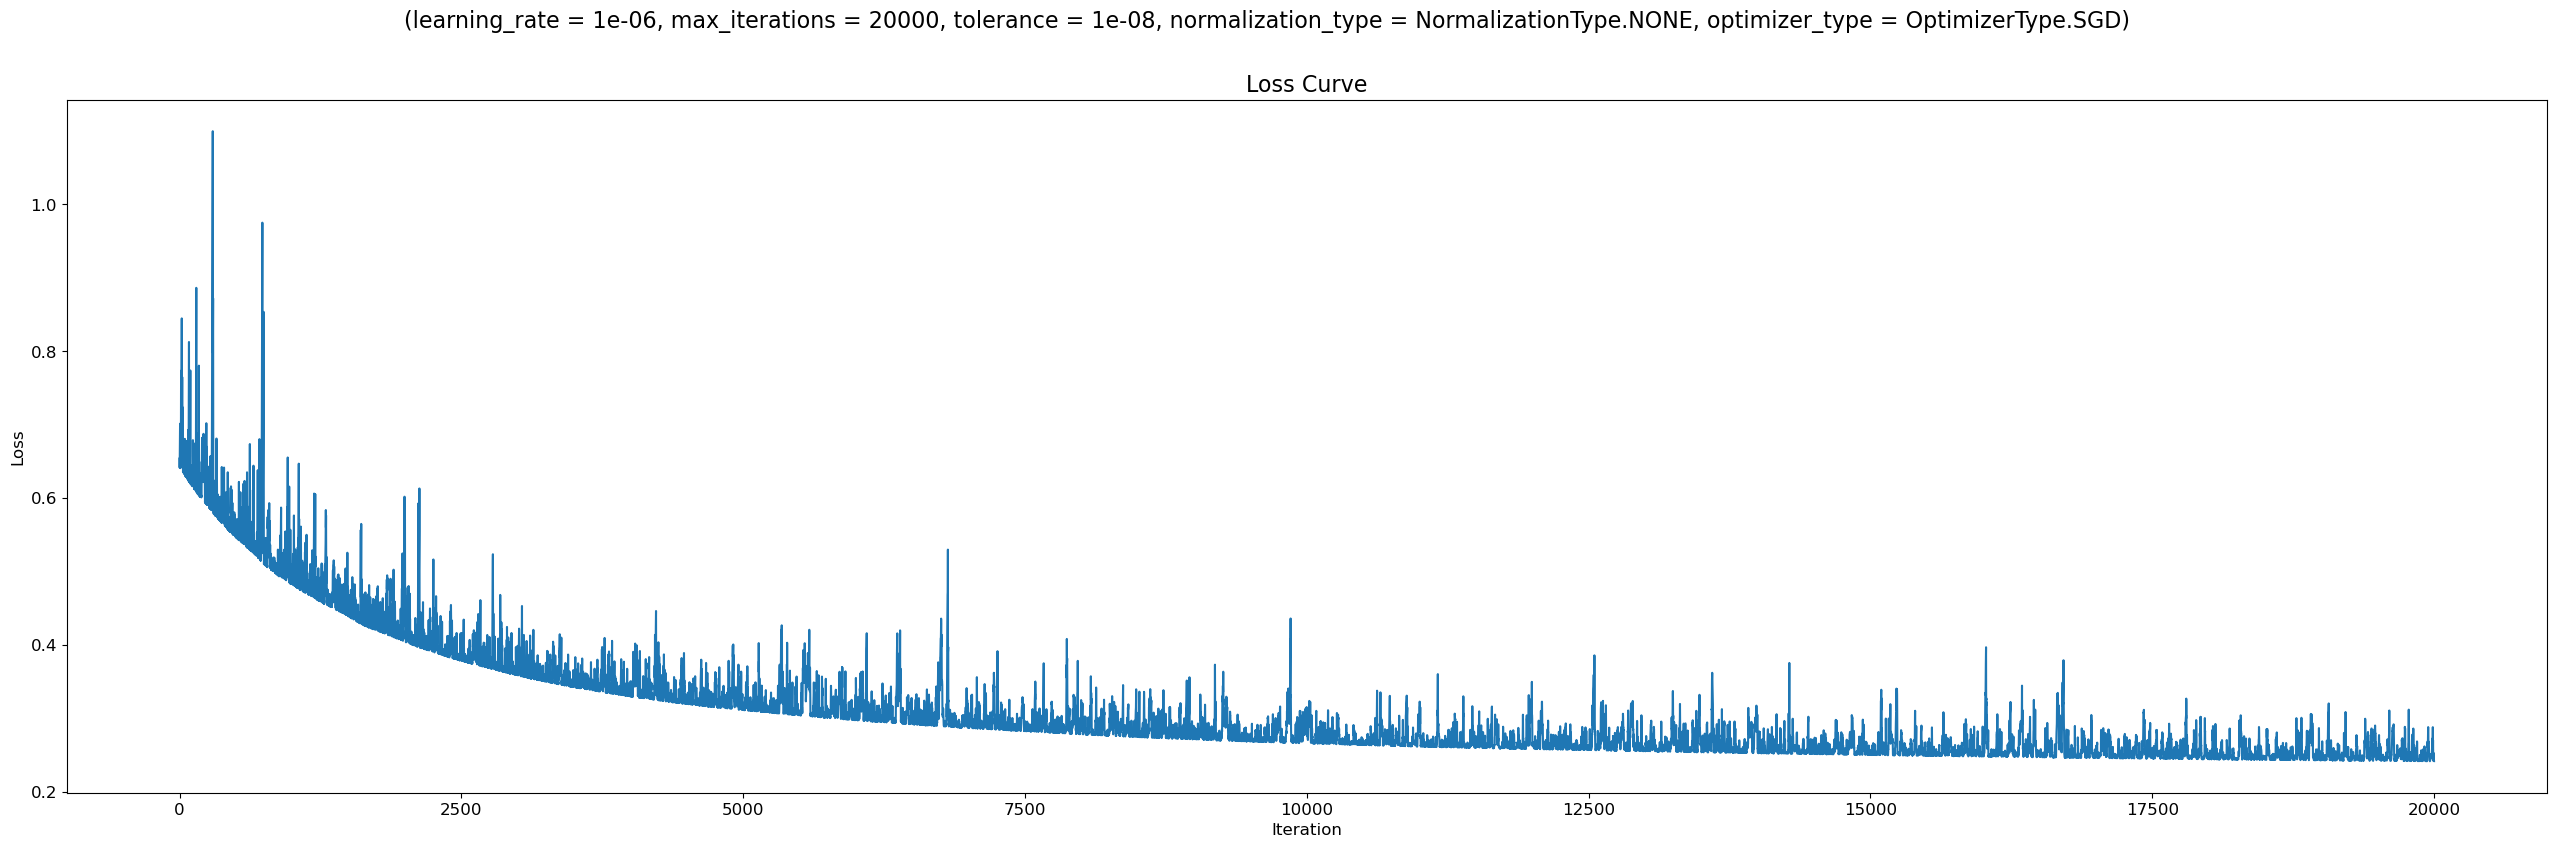

Optimized result:	 [ 0.0177288   0.11585284 -0.07384184 -0.01027282  0.42820291  0.07256408
 -0.01864692 -0.0419192   0.00657815  0.00655723 -0.0775457   0.02778472
 -0.00216538 -0.02143253]
Optimized loss:	 0.1527173209222608
Accuracy (Train):	 0.945054945054945
Accuracy (Test):	 0.9487179487179487
Recall (Train):		 0.9565217391304348
Recall (Test):		 0.96
Precision (Train):	 0.9361702127659575
Precision (Test):	 0.96
F1 Score (Train):	 0.9462365591397849
F1 Score (Test):	 0.96


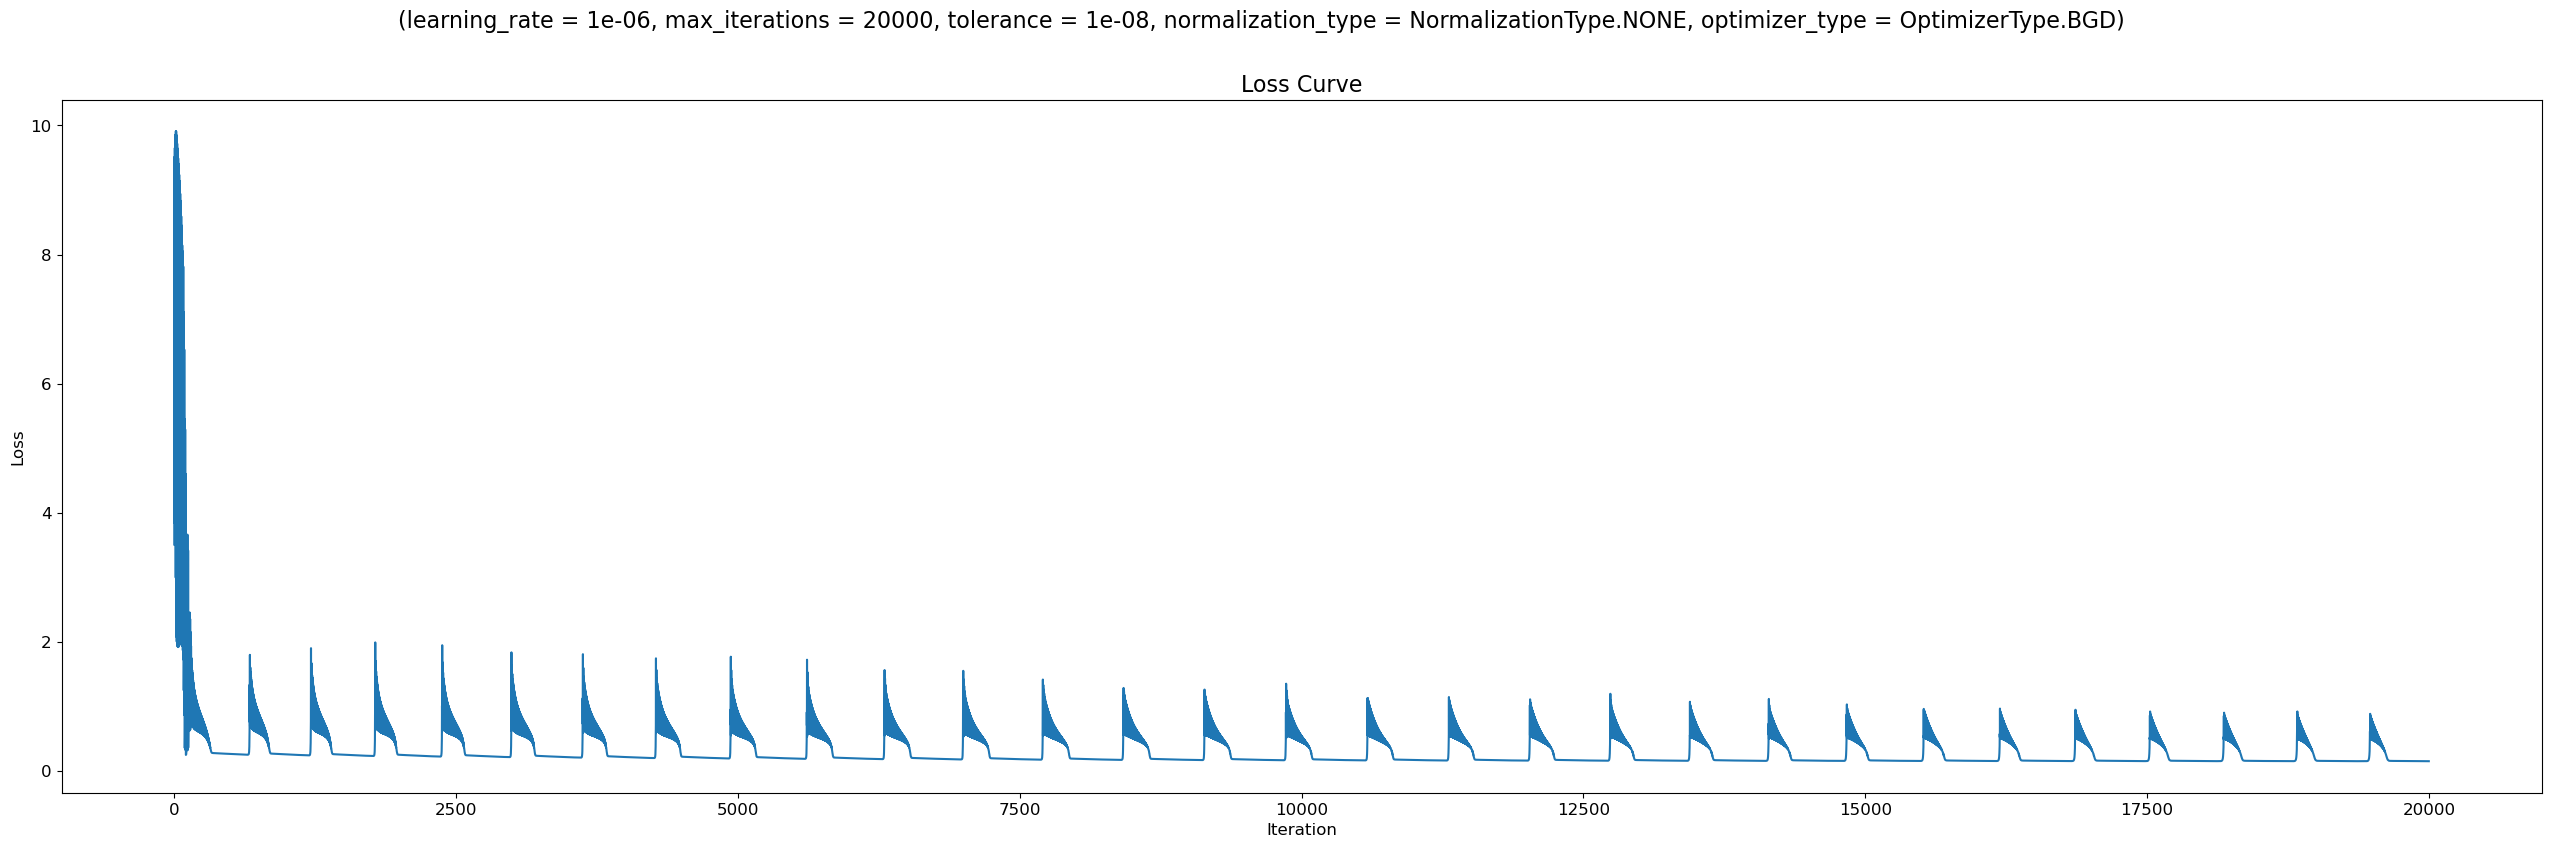

Optimized result:	 [ 0.00375984  0.03171006 -0.00571329  0.00249599  0.10048107  0.07657744
  0.0009952  -0.00252972  0.001596    0.00222847 -0.00788691  0.00510735
  0.00477137 -0.01360849]
Optimized loss:	 0.20134220766689756
Accuracy (Train):	 0.8791208791208791
Accuracy (Test):	 0.9230769230769231
Recall (Train):		 0.8695652173913043
Recall (Test):		 0.92
Precision (Train):	 0.8888888888888888
Precision (Test):	 0.9583333333333334
F1 Score (Train):	 0.8791208791208792
F1 Score (Test):	 0.9387755102040817


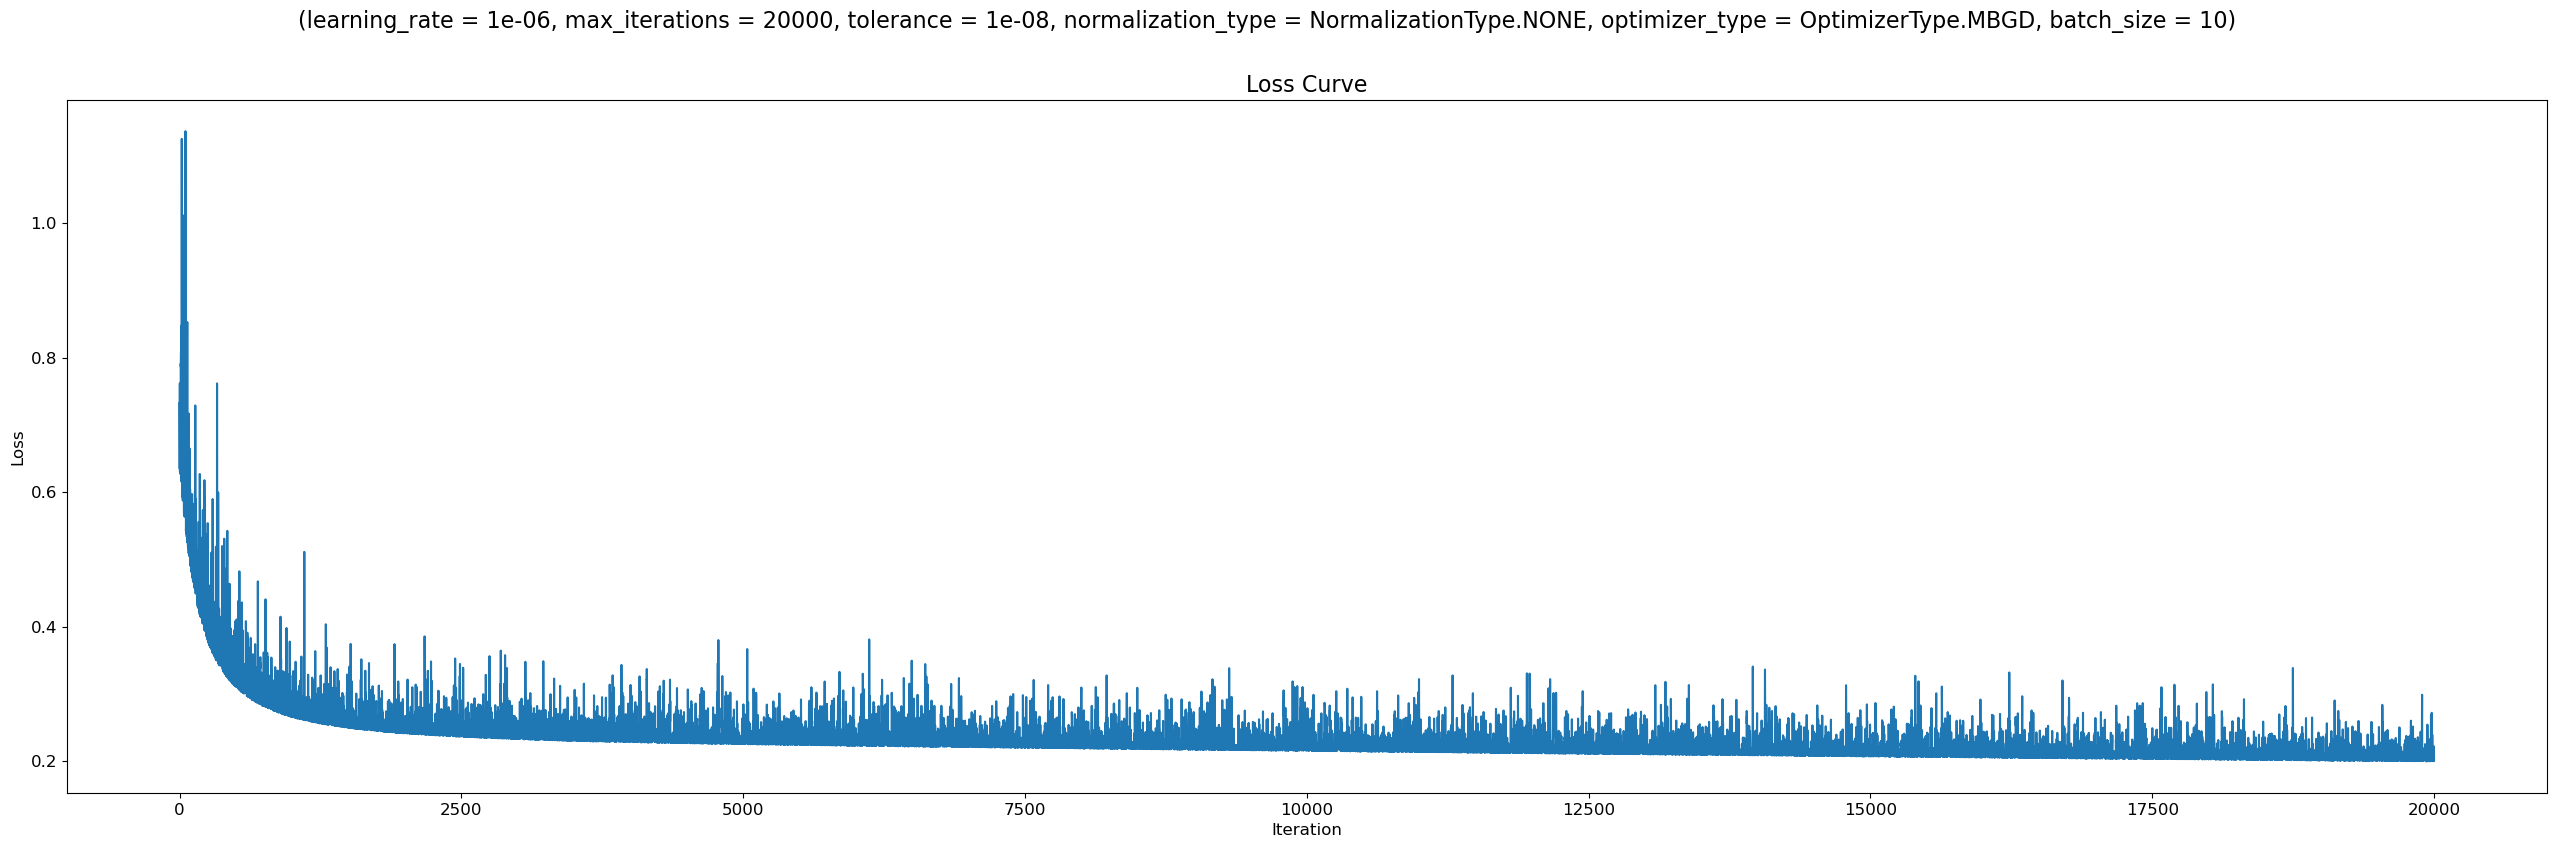

In [233]:
# SGD
model = LogisticRegression(
    dim = X_train.shape[1],
    learning_rate = 0.000001,
    max_iterations = 20000,
    tolerance = 1e-8,
    no_improve_threshold = 10,
    normalization_type = NormalizationType.NONE,
    optimizer_type = OptimizerType.SGD
)
model.optimize(X_train, t_train)
show_results(model, X_train, t_train, X_test, y_test, show_plot = True)

# BGD
model = LogisticRegression(
    dim = X_train.shape[1],
    learning_rate = 0.000001,
    max_iterations = 20000,
    tolerance = 1e-8,
    no_improve_threshold = 10,
    normalization_type = NormalizationType.NONE,
    optimizer_type = OptimizerType.BGD
)
model.optimize(X_train, t_train)
show_results(model, X_train, t_train, X_test, y_test, show_plot = True)

# MBGD
model = LogisticRegression(
    dim = X_train.shape[1],
    learning_rate = 0.000001,
    max_iterations = 20000,
    tolerance = 1e-8,
    no_improve_threshold = 10,
    normalization_type = NormalizationType.NONE,
    optimizer_type = OptimizerType.MBGD,
    batch_size = 10
)
model.optimize(X_train, t_train)
show_results(model, X_train, t_train, X_test, y_test, show_plot = True)

We can see that the model converges most quickly when using BGD, then MBGD, and finally SGD, with is consistent with the conclusion in previous assignments. There are some regular fluctuations in the loss curve when using BGD, try to decrease the learning rate to see if it can be improved:

Optimized result:	 [ 0.01279985  0.08462896 -0.055434   -0.008994    0.29154124  0.05024891
 -0.01332724 -0.03008551  0.00469212  0.00471464 -0.05128867  0.01991758
 -0.0032421  -0.01469615]
Optimized loss:	 0.1532710237512569
Accuracy (Train):	 0.945054945054945
Accuracy (Test):	 0.9487179487179487
Recall (Train):		 0.9565217391304348
Recall (Test):		 0.96
Precision (Train):	 0.9361702127659575
Precision (Test):	 0.96
F1 Score (Train):	 0.9462365591397849
F1 Score (Test):	 0.96


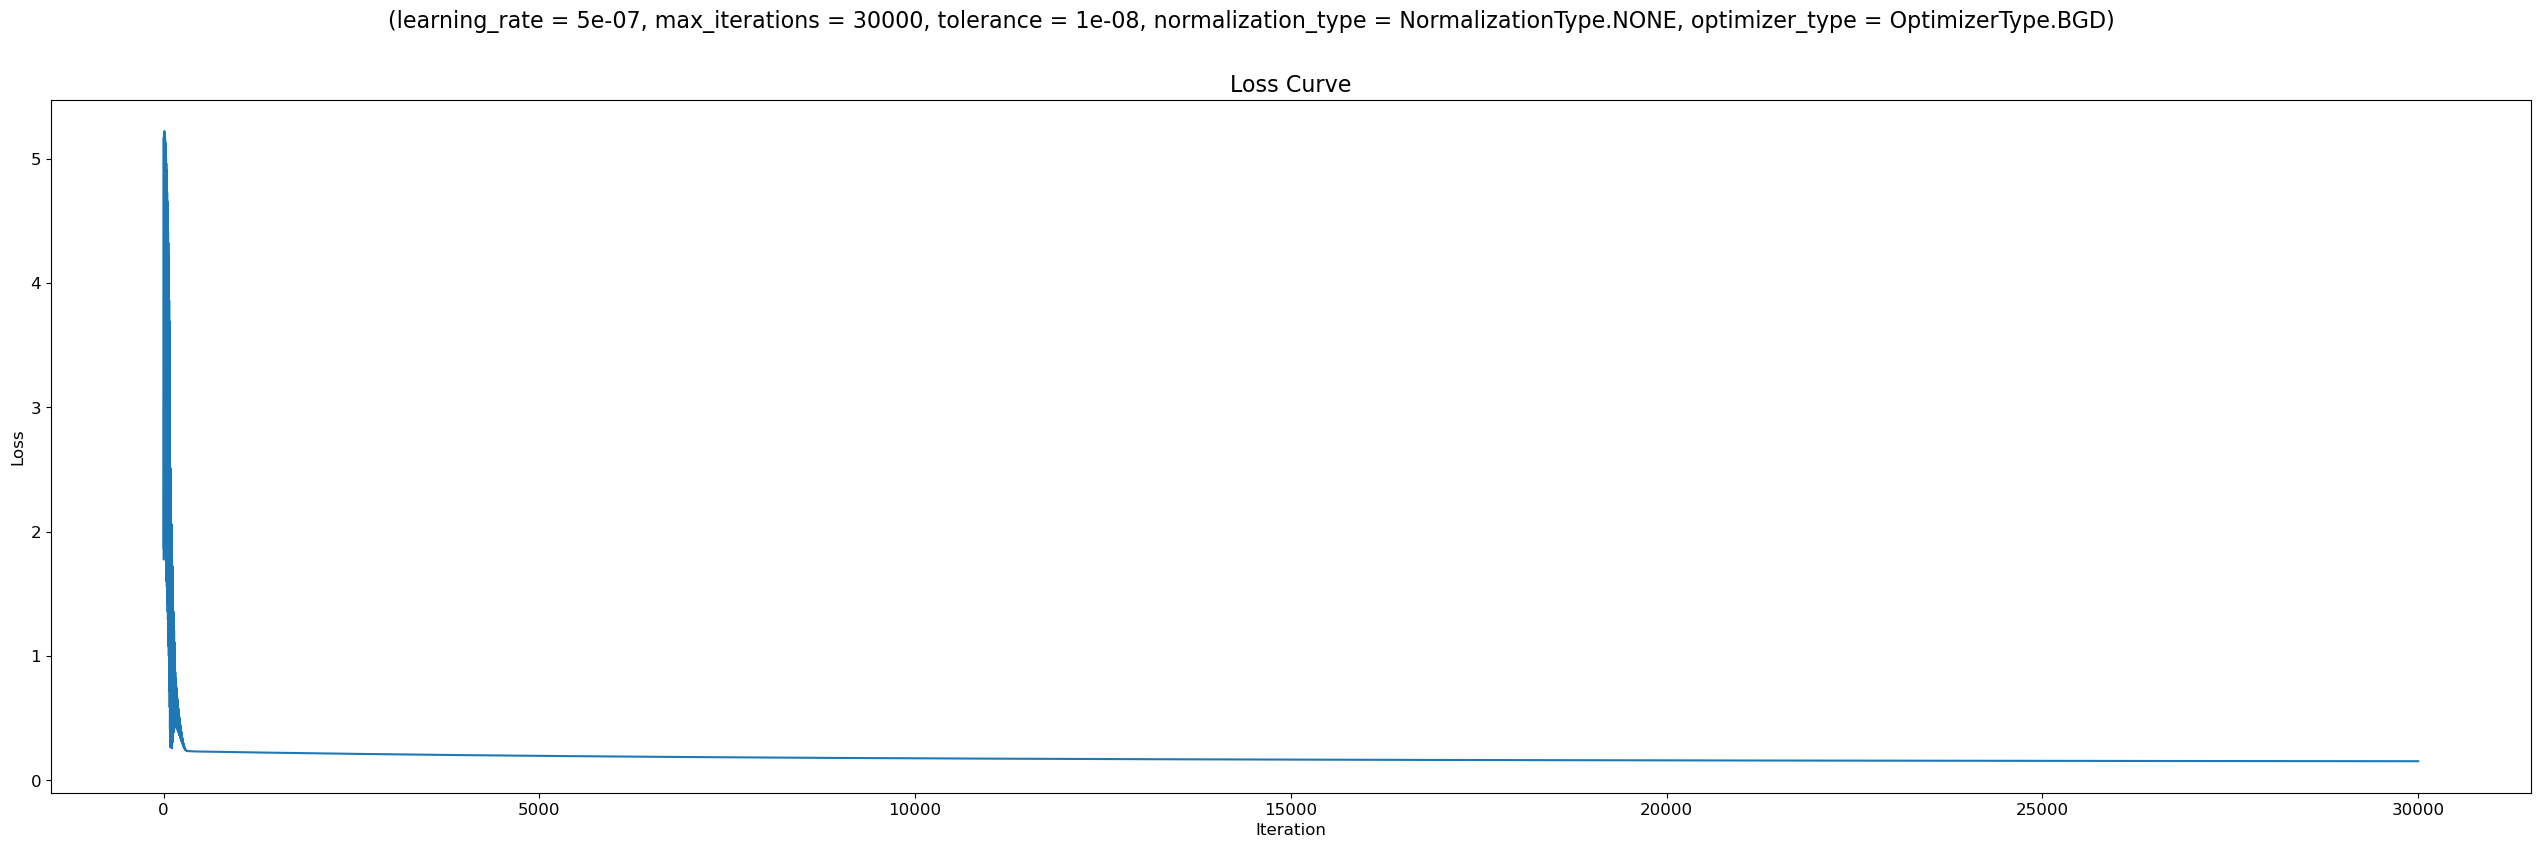

In [242]:
model = LogisticRegression(
    dim = X_train.shape[1],
    learning_rate = 0.0000005,
    max_iterations = 30000,
    tolerance = 1e-8,
    no_improve_threshold = 10,
    normalization_type = NormalizationType.NONE,
    optimizer_type = OptimizerType.BGD
)
model.optimize(X_train, t_train)
show_results(model, X_train, t_train, X_test, y_test, show_plot = True)

The result is that the fluctuations are reduced, while the convergence speed is also reduced. To further improve the performance, a more advanced optimization algorithm can be used.

Then we add normalization to the data:

Converged at iteration 970.
Optimized result:	 [-0.34690791 -1.95116641 -0.66077769 -1.37835493  1.41037965 -0.40391605
 -0.070883   -0.79825354  0.19576536  0.44935152 -1.07019991  0.37023774
 -0.72543869 -2.07574452]
Optimized loss:	 0.02034832647598528
Accuracy (Train):	 1.0
Accuracy (Test):	 0.9743589743589743
Recall (Train):		 1.0
Recall (Test):		 0.96
Precision (Train):	 1.0
Precision (Test):	 1.0
F1 Score (Train):	 1.0
F1 Score (Test):	 0.9795918367346939


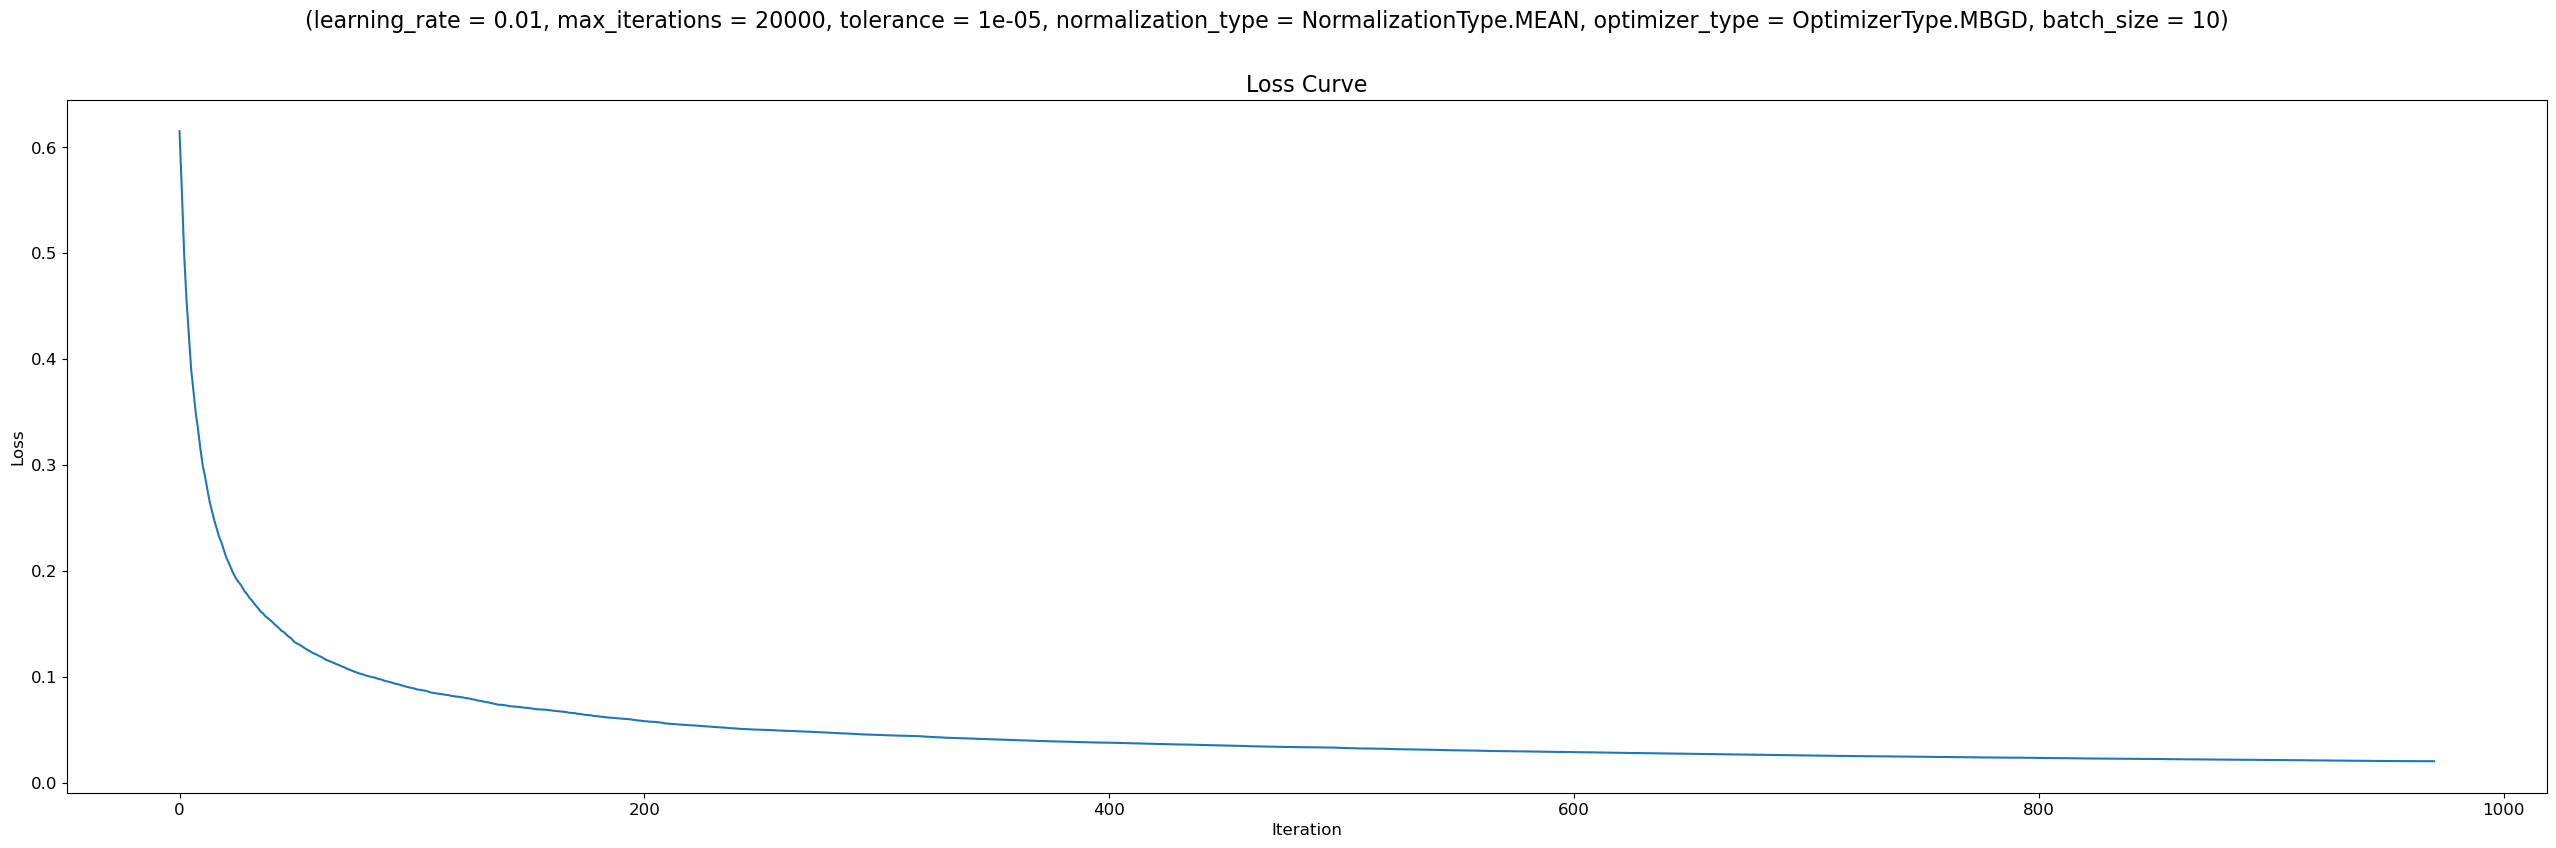

Converged at iteration 5472.
Optimized result:	 [ 5.86366629 -5.00098682 -1.26455807 -3.9038533   4.26884237 -0.55762927
 -0.07234599 -2.2800346   2.12354435  1.81866107 -2.8613552   2.39966268
 -0.82341075 -6.22355851]
Optimized loss:	 0.05985189633735176
Accuracy (Train):	 1.0
Accuracy (Test):	 1.0
Recall (Train):		 1.0
Recall (Test):		 1.0
Precision (Train):	 1.0
Precision (Test):	 1.0
F1 Score (Train):	 1.0
F1 Score (Test):	 1.0


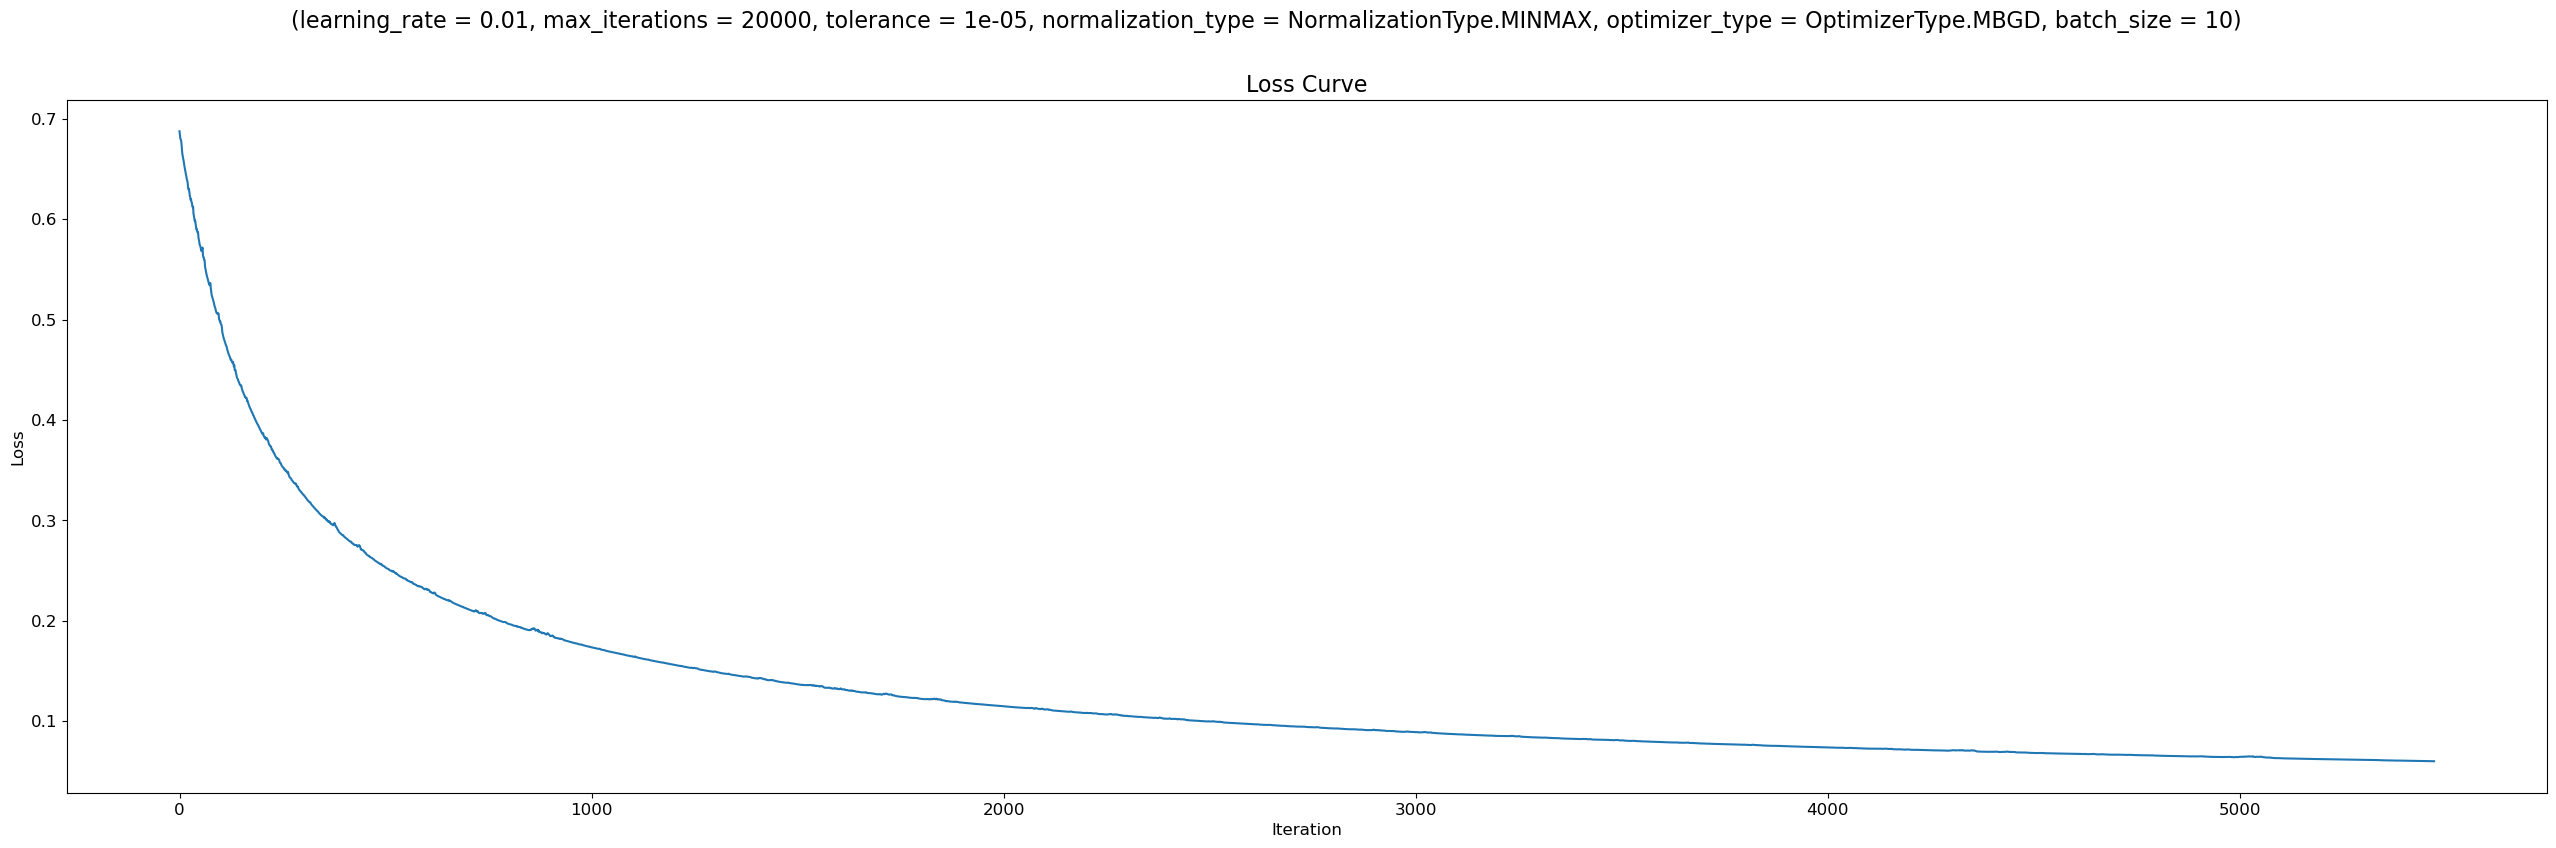

In [245]:
# Mean
model = LogisticRegression(
    dim = X_train.shape[1],
    learning_rate = 0.01,
    max_iterations = 20000,
    tolerance = 1e-5,
    no_improve_threshold = 10,
    normalization_type = NormalizationType.MEAN,
    optimizer_type = OptimizerType.MBGD,
    batch_size = 10
)
model.optimize(X_train, t_train)
show_results(model, X_train, t_train, X_test, y_test, show_plot = True)

# Min-max
model = LogisticRegression(
    dim = X_train.shape[1],
    learning_rate = 0.01,
    max_iterations = 20000,
    tolerance = 1e-5,
    no_improve_threshold = 10,
    normalization_type = NormalizationType.MINMAX,
    optimizer_type = OptimizerType.MBGD,
    batch_size = 10
)
model.optimize(X_train, t_train)
show_results(model, X_train, t_train, X_test, y_test, show_plot = True)

The results show that the convergence speed is improved after normalization, and the loss curve is smoother. The accuracy, recall, precision and f1_score are also improved.

Finally, we compare the performance of the perceptron (in previous assignments) and logistic regression models.

The loss function used by the perceptron is a segmented function, and data points that are correctly and incorrectly predicted during training affect the loss function differently, as well as the gradient. Correctly classified points do not contribute to the parameter update, and the trained decision boundary is likely to be close to the limit case, resulting in poor generalisation.Logistic Regression uses a cross-entropy loss function, which is continuously derivable, and applies negative log-likelihood estimation to optimise the computation process.

Perceptron can converge for linearly divisible datasets, but for linearly indistinguishable datasets, it may result in failure to converge, and Logistic Regression can handle linearly indistinguishable datasets.

In addition, the output values of Logistic Regression can be viewed as probabilities, providing richer information.